In [141]:
words = open("names.txt", "r").read().splitlines()

len(words)

32033

## Bigrams Model using NN

In [142]:
import torch

In [143]:
# We need to get all the unique character in the dataset of number which is simply all 26 character of the alphabet 
a = set(''.join(words)) # gets all the unique characters from the huge string 
chars = sorted(list(set(''.join(words)))) # we want it as a sorted list 
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [144]:
# Because computers only understand numbers, we need to map each character to a number 
# So we need a look up table for 
# stoi - string to interger
# itos = integer to string 

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."] = 0
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [145]:
# integer to string 
# get the reverse of stoi 
itos = {i: s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [146]:
# create training set of all the bigrams 

xs, ys = [], [] # training set: inputs and labels 

for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] # map ch1 to its integer value 
        ix2 = stoi[ch2] # map ch2 to its integer value 
        print(ch1, ch2)
        print(ix1, ix2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
        

. e
0 5
e m
5 13
m m
13 13
m a
13 1
a .
1 0


In [147]:
xs 

tensor([ 0,  5, 13, 13,  1])

In [148]:
ys

tensor([ 5, 13, 13,  1,  0])

In [149]:
# above, xs is the input dataset, and ys is the target dataset 
# when xs = 0 (char at index 0), we want our NN to predict 5 (assign high probability to the char at index 5)
# when xs = 5 (char at index 5), we want out NN to predict 13 (assign high probability to char at index 13)
# and so on ... 

# xs - input data 
# ys - target output 

# xs and ys is our simple dataset and we are going to create a simple neural network which will be trained on the xs and ys dataset 

In [150]:
# the simple mathematics of a neural net is that we multiply a weight by the input x plus a bias b
# wx + b 

# From the xs input data, out input values are integer values and we know that we cannot use integer values as an input into the NN 
# Also feeding the input values as numbers with magnitude will lead the NN to treat these numbers like there is a numerical relationship
# This false numerical relationship will mislead the NN and thats not what we want 
# 
# To resolve this, we encode the inputs using vectors 
# Each input is represented as a vector of all zeros except a single 1 at the character's index 
# 'a' (index 1) → [0, 1, 0, 0, 0, ...]
# 'b' (index 2) → [0, 0, 1, 0, 0, ...]
# 'c' (index 3) → [0, 0, 0, 1, 0, ...]

# By encoding the inputs as vectors, every character is equidistant from every other character 
# no character is numerically larger, smaller, or closer to another

import torch.nn.functional as F 
xenc = F.one_hot(xs, num_classes=27).float()
xenc # This gives us five rows with 27 columns 
# each row is a seperate input encoded with the index value position set to 1 

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [151]:
xenc.shape

torch.Size([5, 27])

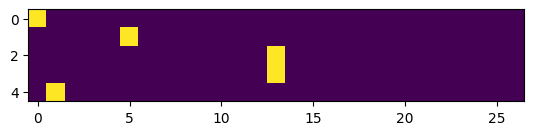

In [152]:
import matplotlib.pyplot as plt
plt.imshow(xenc)

In [153]:
# One problem you should always watch out for is the dtype of your inputs into a NN 
# The datatype should always be floats which can take on a range of values 

xenc.dtype # was initially int dtype until we casted it above 

# so solve this, we cast xenc to float when we encode above 

torch.float32

In [154]:
# create random weights 
g = torch.Generator().manual_seed(2147483547)
W = torch.randn((27, 27), generator=g, requires_grad=True)
W

tensor([[-1.5172e+00, -1.2196e+00,  1.0568e+00, -8.7049e-01,  9.8910e-01,
          9.8736e-01,  1.3131e+00, -1.3862e+00,  6.1244e-01,  5.5360e-01,
         -1.0351e+00, -5.0780e-01, -2.1199e+00,  8.5033e-01, -2.2822e-02,
          3.1539e-01,  5.7709e-01, -3.2228e-01, -1.6735e+00,  6.8428e-01,
          1.3820e+00,  9.7418e-01,  1.4191e+00,  1.5195e+00, -6.1074e-02,
         -4.2446e-01, -3.1024e-01],
        [-1.0032e+00,  6.2306e-01, -2.1592e+00,  6.4354e-01,  2.2729e+00,
          3.8105e-01,  4.0565e-02, -2.1663e+00,  1.3888e+00, -1.1336e+00,
          5.0226e-01,  7.2800e-01,  6.2240e-01,  1.4465e+00,  4.7198e-01,
         -7.7242e-01, -1.5088e+00, -1.2487e+00, -3.1200e-01, -1.1900e+00,
          4.9416e-01,  2.9313e-01,  9.6920e-01, -4.0847e-01, -5.9314e-02,
          1.1802e+00, -1.1926e+00],
        [-4.7564e-01, -1.7937e-01,  3.8387e-01,  1.1067e+00, -1.5056e-01,
          8.7597e-02, -4.2130e-01,  9.7718e-01, -6.1029e-02, -8.3716e-01,
          2.0717e-01, -9.4811e-01,  2.02

In [211]:
# perform x @ W 
# x = (5, 27) 
# W = (27, 27)

# The idea is that each of the 5 rows has 27 columns (dimension)
# Each of the 27 columns (dimension) will represent probability distribution for the next characters - 
# it will represent the probabilities of the next characters 

# We are going to treat the ypred as log counts and exponentiate them 
logits = xenc @ W # intepret this as the log-counts

# The two lines of code below is known as softmax - takes logits (output of an NN layer) as inputs, exponentiates and normalizes which will always sum to 1 
counts = logits.exp() # exponentiate logits to convert negative logits to its positive equivalent 
probs = counts / counts.sum(1, keepdim=True) # Normalize each row independently so that it sums to 1 - this will represent the probabilities of the next character given the input of that row 

# probs becomes our ypred = (5, 27)

# Because of the transformation (calculations) done above, we can now interpret probs as the probabilities of the next characters
probs # see this as ypred

# In Summary, this block of code is regarded as the forward pass
# It is made up of differentiable operations 
# We can backpropagate through all of the operation which means: 
# --- we can calculate the gradient of each operation which will tell us how each weight value affects the final loss 
# --- then we can tune the weight appropriately to minimize the final loss 

# Also consider the loss calculation as part of the forward pass 

tensor([[0.0049, 0.0066, 0.0638, 0.0093, 0.0596, 0.0649, 0.0823, 0.0056, 0.0410,
         0.0387, 0.0079, 0.0134, 0.0027, 0.0520, 0.0218, 0.0305, 0.0396, 0.0161,
         0.0042, 0.0440, 0.0881, 0.0588, 0.0914, 0.1010, 0.0209, 0.0146, 0.0163],
        [0.0150, 0.0451, 0.0679, 0.0034, 0.0143, 0.0737, 0.0583, 0.0174, 0.0233,
         0.0309, 0.0135, 0.0213, 0.0586, 0.0260, 0.0308, 0.0221, 0.0454, 0.0092,
         0.0145, 0.0262, 0.0272, 0.1055, 0.0184, 0.0193, 0.1254, 0.0570, 0.0304],
        [0.0108, 0.0125, 0.0559, 0.0053, 0.0837, 0.0068, 0.0195, 0.0084, 0.0577,
         0.0481, 0.0063, 0.0047, 0.0193, 0.1905, 0.0559, 0.0052, 0.0009, 0.0546,
         0.0979, 0.0145, 0.0035, 0.0040, 0.0680, 0.0191, 0.0257, 0.0207, 0.1004],
        [0.0108, 0.0125, 0.0559, 0.0053, 0.0837, 0.0068, 0.0195, 0.0084, 0.0577,
         0.0481, 0.0063, 0.0047, 0.0193, 0.1905, 0.0559, 0.0052, 0.0009, 0.0546,
         0.0979, 0.0145, 0.0035, 0.0040, 0.0680, 0.0191, 0.0257, 0.0207, 0.1004],
        [0.0089, 0.0414,

In [212]:
probs[0].sum()

tensor(1., grad_fn=<SumBackward0>)

In [213]:
# derive the loss 

xs 

tensor([ 0,  5, 13, 13,  1])

In [214]:
ys 

tensor([ 5, 13, 13,  1,  0])

In [215]:
# The probs we want to be higher based ys, is the probs at the index in ys 

probs[0, 5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0]

# a better way of writing the code above in pytorch 
probs[torch.arange(5), ys] # this gives us the probabilities the NN assigns to the correct next characters 

# then we will do the following 
# -- convert them to log probs 
# -- get the average (mean)
# -- get the negative log-likelihood to give us the loss value

loss = -probs[torch.arange(5), ys].log().mean()

print(loss.item())

# The loss calculation is also part of the forward pass 

3.429969072341919


In [216]:
# backward pass 

# step 1: Make sure all the gradients as set to zero 
W.grad = None # This is also valid as pytorch inteprets this as setting grad of W to 0 but its more efficient because it uses less memory

# step 2: backpropagation 
loss.backward() # fills in the gradients of all the operations in the forward pass, from the loss back to the weights of the inputs 

# step 3: Gradient descent 
W.data -= 0.1 * W.grad

In [217]:
W.grad

tensor([[ 0.0010,  0.0013,  0.0128,  0.0019,  0.0119, -0.1870,  0.0165,  0.0011,
          0.0082,  0.0077,  0.0016,  0.0027,  0.0005,  0.0104,  0.0044,  0.0061,
          0.0079,  0.0032,  0.0008,  0.0088,  0.0176,  0.0118,  0.0183,  0.0202,
          0.0042,  0.0029,  0.0033],
        [-0.1982,  0.0083,  0.0005,  0.0085,  0.0425,  0.0065,  0.0046,  0.0005,
          0.0178,  0.0014,  0.0073,  0.0092,  0.0083,  0.0188,  0.0071,  0.0021,
          0.0010,  0.0013,  0.0033,  0.0014,  0.0073,  0.0060,  0.0117,  0.0030,
          0.0042,  0.0144,  0.0014],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000